# Hertzsprung-Russell Diagram

In [ ]:
%matplotlib notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read in the relevant data from the files

# I a creating function to read all of my files as I import them

# Evolutionary Track
def m_text(text_f):
  file = pd.read_csv(text_f, comment='#', sep='\s+' ,header=22, on_bad_lines='skip', skip_blank_lines=True,
    names=['Mini Msun','track','Rot','Time','Mass (Msun)','logL [Lsun]','logTe [K]','X','Y','C12','C13','N14','O16','O17','O18','Ne20','Ne22','Al26'])
  return file

# Isochrones
def iso_text(text_f):
  file = pd.read_csv(text_f, comment='#', sep='\s+',header=22, on_bad_lines='skip', skip_blank_lines=True,
    names=['Mini Msun','track','Rot','Time','Mass (Msun)','logL [Lsun]','logTe [K]','X','Y','C12','C13','N14','O16','O17','O18','Ne20','Ne22','Al26'])
  return file

# ZAMS File
def zams_text(text_f):
  file = pd.read_csv(text_f, comment='#', sep='\s+',header=22, on_bad_lines='skip', skip_blank_lines=True,
    names=['Mini Msun','track','Rot','Time','Mass (Msun)','logL [Lsun]','logTe [K]','X','Y','C12','C13','N14','O16','O17','O18','Ne20','Ne22','Al26'])
  return file


In [ ]:
# This section is to read the files from my google drive, and send them through the functions I created above
from ast import Is

# ZAMS
zams = zams_text('/content/drive/My Drive/Astro_Files/HR_Diagram/ZAMS.txt')

# Evolutionary Tracks
Evo5M = m_text('/content/drive/My Drive/Astro_Files/HR_Diagram/Evolution5M.txt')
Evo120M = m_text('/content/drive/My Drive/Astro_Files/HR_Diagram/Evolution120M.txt')

# Isochones
Iso6_5 = iso_text('/content/drive/My Drive/Astro_Files/HR_Diagram/Isochrones6.5.txt')
Iso7_5 = iso_text('/content/drive/My Drive/Astro_Files/HR_Diagram/Isochrones7.5.txt')
Iso8_5 = iso_text('/content/drive/My Drive/Astro_Files/HR_Diagram/Isochrones8.5.txt')
Iso9_5 = iso_text('/content/drive/My Drive/Astro_Files/HR_Diagram/Isochrones9.5.txt')
Iso10_1 = iso_text('/content/drive/My Drive/Astro_Files/HR_Diagram/Isochrones10.1.txt')

In [ ]:
# Include the relevant parameters of the Sun to plot. Remember that the values must be in the
# form of an array. Inlcude your source (e.g. as a comment, or a reference at the end of the notebook)

lum_sun = math.log(1) # I am using one because our lumonsity is in terms of the sun on the y-axis
teff_sun = 5772 # Effective temperature of the sun

In [ ]:
from re import I
# Create the appropriate arrays of the data you will use to plot
# This is converting my temperature from log to normal units [K]

# ZAMS
zamsT = 10**zams['logTe [K]']

# Evolutionary Tracks
Evo5MT = 10**Evo5M['logTe [K]']
Evo120MT = 10**Evo120M['logTe [K]']

# Isochrones
Iso6_5T = 10**Iso6_5['logTe [K]']
Iso7_5T = 10**Iso7_5['logTe [K]']
Iso8_5T = 10**Iso8_5['logTe [K]']
Iso9_5T = 10**Iso9_5['logTe [K]']
Iso10_1T = 10**Iso10_1['logTe [K]']

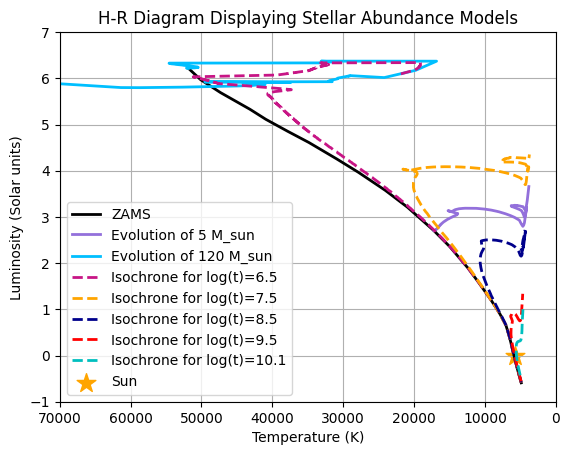

In [ ]:
# Create your figure

# Plot ZAMS (Zero-Age Main Sequence)
fig = plt.figure()
axes = fig.add_subplot(111)

# Plotting ZAMS
axes.plot(zamsT, zams['logL [Lsun]'], label='ZAMS', color='black', linewidth=2)

# Plotting Evolution
axes.plot(Evo5MT, Evo5M['logL [Lsun]'], label='Evolution of 5 M_sun', color='mediumpurple',linewidth=2)
axes.plot(Evo120MT, Evo120M['logL [Lsun]'], label='Evolution of 120 M_sun', color='deepskyblue',linewidth=2)

# Plotting the Isochrones
axes.plot(Iso6_5T, Iso6_5['logL [Lsun]'], label='Isochrone for log(t)=6.5', color='mediumvioletred',linewidth=2, linestyle='--')
axes.plot(Iso7_5T, Iso7_5['logL [Lsun]'], label='Isochrone for log(t)=7.5', color='orange',linewidth=2, linestyle='--')
axes.plot(Iso8_5T, Iso8_5['logL [Lsun]'], label='Isochrone for log(t)=8.5', color='darkblue',linewidth=2, linestyle='--')
axes.plot(Iso9_5T, Iso9_5['logL [Lsun]'], label='Isochrone for log(t)=9.5', color='red',linewidth=2, linestyle='--')
axes.plot(Iso10_1T, Iso10_1['logL [Lsun]'], label='Isochrone for log(t)=10.1', color='c',linewidth=2, linestyle='--')

# Plotting the Sun
axes.scatter(teff_sun,lum_sun,color = 'orange',label='Sun',marker='*', s = 200)

# Plot Editing
plt.gca().invert_xaxis()  # Temperature decreases to the right
axes.set_title('H-R Diagram Displaying Stellar Abundance Models')
axes.set_xlabel('Temperature (K)')
axes.set_xlim(70000, 0)
axes.set_ylabel('Luminosity (Solar units)')
axes.set_ylim(-1, 7)
axes.legend(loc='best')
axes.grid(True)
plt.show()


In [ ]:
# References

# Luminosity of the sun: https://www.cosmos.esa.int/web/cesar/the-hertzsprung-russell-diagram
# Effective temperature of the sun: https://nssdc.gsfc.nasa.gov/planetary/factsheet/sunfact.html#:~:text=Surface%20Gas%20Pressure%20(top%20of,Si%20%2D%2032%2C%20S%20%2D%2015